In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [3]:
DATA_PATH = "../data/ai4i2020.csv"
df = pd.read_csv(DATA_PATH)

target_col = "Machine failure"
feature_col = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]" 
]
X = df[feature_col]
y = df[target_col]

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,
    random_state=42,
    stratify=y_train_full
)

In [6]:
categorical_features = ["Type"]
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]" 
]

rf_preprocessing = ColumnTransformer(
    transformers=[
        ("category", OneHotEncoder(handle_unknown="ignore"),categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

random_forest_model = Pipeline(
    steps= [
        ("preprocessing", rf_preprocessing),
        ("classifier", RandomForestClassifier(
            n_estimators=200, class_weight="balanced",random_state=42
        ))
    ]
)
random_forest_model.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('category', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
chosen_threshold = 0.3

test_probabilities = random_forest_model.predict_proba(X_test)[:, 1]
test_predictions = (test_probabilities >= chosen_threshold).astype(int)

In [8]:
test_results = X_test.copy()

test_results["actual_failure"] = y_test
test_results["predicted_failure"] = test_predictions
test_results["failure_probability"] = test_probabilities

test_results.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],actual_failure,predicted_failure,failure_probability
2997,L,300.5,309.8,1345,62.7,153,0,0,0.130
4871,L,303.7,312.4,1513,40.1,135,0,0,0.000
3858,L,302.5,311.4,1559,37.6,209,0,0,0.095
951,H,295.6,306.3,1509,35.8,60,0,0,0.010
6463,H,300.5,310.0,1358,60.4,102,0,0,0.120


In [9]:
false_positives = test_results[
    (test_results["actual_failure"] == 0) &
    (test_results["predicted_failure"] == 1)
]

false_negatives = test_results[
    (test_results["actual_failure"] == 1) &
    (test_results["predicted_failure"] == 0)
]

In [10]:
len(false_positives), len(false_negatives)

(21, 21)

In [11]:
false_positives.sort_values("failure_probability", ascending=False).head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],actual_failure,predicted_failure,failure_probability
3794,M,302.2,310.8,1356,48.3,36,0,1,0.570
4231,L,302.2,310.8,1340,47.8,54,0,1,0.535
7677,L,300.6,311.7,1428,52.6,208,0,1,0.515
6612,L,301.6,310.6,1222,70.0,62,0,1,0.495
6127,L,300.9,310.9,1228,66.4,109,0,1,0.495
3596,L,301.7,310.5,1354,50.0,169,0,1,0.480
3866,L,302.6,311.6,1311,53.2,0,0,1,0.470
3843,L,302.5,311.2,1227,60.1,167,0,1,0.450
5692,M,302.4,311.9,1313,55.7,102,0,1,0.430
3729,M,302.4,311.3,1312,61.5,85,0,1,0.430


In [12]:
false_negatives.sort_values("failure_probability", ascending=True).head(10)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],actual_failure,predicted_failure,failure_probability
9174,L,297.8,308.9,1871,25.6,200,1,0,0.000
1996,M,298.4,308.0,1416,38.2,198,1,0,0.000
8506,L,298.4,309.6,1710,27.3,163,1,0,0.000
2671,M,299.7,309.3,1399,41.9,221,1,0,0.010
7087,L,300.6,310.3,1648,30.5,217,1,0,0.020
7849,M,300.3,311.7,1374,47.9,222,1,0,0.025
2941,M,300.7,309.6,1996,19.8,203,1,0,0.025
3695,L,302.2,311.3,1530,37.3,207,1,0,0.035
7884,L,300.8,312.4,1465,59.1,91,1,0,0.055
4034,L,302.0,310.8,1615,29.0,235,1,0,0.090


False positives are normal machinie that the model flagged as failures.
False negatives are failed machines that the model missed.
In maintenance, false negatives are usually more serious because they may lead to unexpected downtime or damage.

In [13]:
false_positives[numeric_features + ["failure_probability"]].mean()

Air temperature [K]         301.838095
Process temperature [K]     311.114286
Rotational speed [rpm]     1324.142857
Torque [Nm]                  56.200000
Tool wear [min]             108.095238
failure_probability           0.411905
dtype: float64

In [14]:
false_negatives[numeric_features + ["failure_probability"]].mean()

Air temperature [K]         300.661905
Process temperature [K]     310.252381
Rotational speed [rpm]     1477.190476
Torque [Nm]                  44.419048
Tool wear [min]             184.809524
failure_probability           0.125476
dtype: float64

In [15]:
test_results[numeric_features + ["failure_probability"]].mean()

Air temperature [K]         300.002850
Process temperature [K]     310.003550
Rotational speed [rpm]     1536.453000
Torque [Nm]                  39.921100
Tool wear [min]             109.015000
failure_probability           0.029653
dtype: float64

In [16]:
false_positives["Type"].value_counts()

Type
L    13
M     8
Name: count, dtype: int64

In [17]:
false_negatives["Type"].value_counts()

Type
L    11
M     7
H     3
Name: count, dtype: int64

In [18]:
test_results["Type"].value_counts()

Type
L    1170
M     616
H     214
Name: count, dtype: int64

- The FP have much higher avg torque than the full test set. This     suggests the model sometimes treats high torque as a failure sigal even when the machine did not fail.
- The FN have higher tool wear than the full test set, but their avg predicted failure probability is still low. This means some failed machines do not look risky enough based on the feature patterns learned by the model so far.
- Most wrong predictions are product type L, but type L is also the most common product type in the test set, so this alone does not prove a type specific problem

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
test_results["prediction_group"] = "correct"

test_results.loc[
    (test_results["actual_failure"] == 0) &
    (test_results["predicted_failure"] == 1),
    "prediction_group"
] = "false positive"

test_results.loc[
    (test_results["actual_failure"] == 1) &
    (test_results["predicted_failure"] == 0),
    "prediction_group"
] = "false negative"

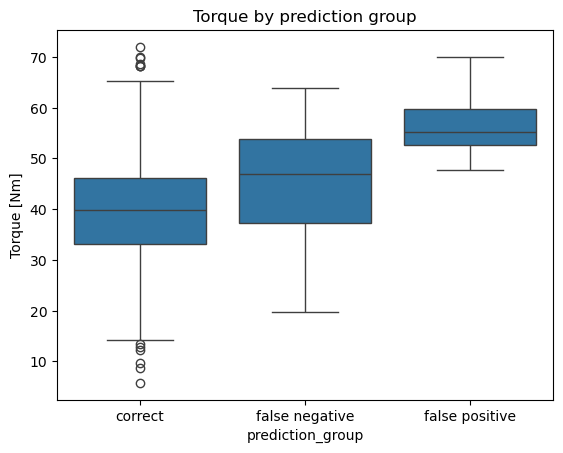

In [21]:
sns.boxplot(
    data=test_results,
    x="prediction_group",
    y="Torque [Nm]"
)

plt.title("Torque by prediction group")
plt.show()

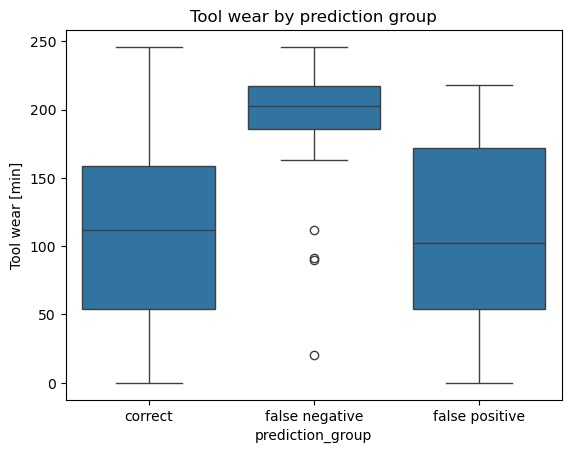

In [22]:
sns.boxplot(
    data=test_results,
    x="prediction_group",
    y="Tool wear [min]"
)

plt.title("Tool wear by prediction group")
plt.show()

The plots make the error patterns easier to inspect.